In [1]:
# ---------- imports + global settings ----------

import numpy as np
import pandas as pd
import scipy
import scipy.stats
import scipy.optimize
import matplotlib.pyplot as plt
from IPython.display import display

# --- MULTI-SEED SETUP ---
rng = np.random.default_rng(0)

Rmax = 1.0
response_sd_default = 0.18

num_x_default = 301 
num_r_default = 251

n_starts_default = 12
maxiter_default = 150

n_steps_main = 5000
burn_in_main = 500

p_switch_main = 0.01
seed_list = list(range(20))

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

In [2]:
# ---------- summary statistic helpers ----------

def sem(x):
    x = pd.Series(x).dropna().values
    n = len(x)
    if n <= 1:
        return np.nan
    return np.std(x, ddof=1) / np.sqrt(n)

In [3]:
# ---------- default contexts ----------

contexts_mean_default = {
    0: {"name": "low-mean",  "mu": -2.0, "sigma": 1.0},
    1: {"name": "high-mean", "mu":  2.0, "sigma": 1.0},
}

contexts_var_default = {
    0: {"name": "low-var",  "mu": 0.0, "sigma": 0.7},
    1: {"name": "high-var", "mu": 0.0, "sigma": 1.8},
}

In [4]:
# ---------- environment constructors ----------

def make_mean_contexts(delta, sigma=1.0):
    half = delta / 2.0
    return {
        0: {"name": "low-mean",  "mu": -half, "sigma": sigma},
        1: {"name": "high-mean", "mu":  half, "sigma": sigma},
    }


def make_variance_contexts(sigma_low, sigma_high, mu=0.0):
    return {
        0: {"name": "low-var",  "mu": mu, "sigma": sigma_low},
        1: {"name": "high-var", "mu": mu, "sigma": sigma_high},
    }

In [5]:
# ---------- encoding and grid helpers ----------

def logistic(x, a, b, Rmax=Rmax):
    return Rmax / (1.0 + np.exp(-a * (x - b)))

def make_x_grid(contexts, n_std=5, num_x=num_x_default):
    mus = [c["mu"] for c in contexts.values()]
    sigmas = [c["sigma"] for c in contexts.values()]

    x_min = min(mu - n_std * sigma for mu, sigma in zip(mus, sigmas))
    x_max = max(mu + n_std * sigma for mu, sigma in zip(mus, sigmas))

    pad = 0.5
    return np.linspace(x_min - pad, x_max + pad, num_x)


def normal_pmf_on_grid(x_grid, mu, sigma):
    px = scipy.stats.norm.pdf(x_grid, loc=mu, scale=sigma)
    px = np.maximum(px, 1e-300)
    px /= px.sum()
    return px


def mixture_prior_pmf(contexts, x_grid, weights=None):
    keys = list(contexts.keys())

    if weights is None:
        weights = {k: 1.0 / len(keys) for k in keys}

    px = np.zeros_like(x_grid, dtype=float)

    for k in keys:
        px += weights[k] * normal_pmf_on_grid(
            x_grid,
            contexts[k]["mu"],
            contexts[k]["sigma"],
        )

    px = np.maximum(px, 1e-300)
    px /= px.sum()
    return px

In [6]:
# ---------- posterior and decoding helpers ----------

def posterior_stats_from_prior_one_neuron(
    x_grid,
    px,
    a,
    b,
    response_sd=response_sd_default,
    Rmax=Rmax,
    num_r=num_r_default,
):
    mean_responses = logistic(x_grid, a, b, Rmax=Rmax)

    r_min = mean_responses.min() - 4 * response_sd
    r_max = mean_responses.max() + 4 * response_sd
    r_grid = np.linspace(r_min, r_max, num_r)

    pr_given_x_density = scipy.stats.norm.pdf(
        r_grid[None, :],
        loc=mean_responses[:, None],
        scale=response_sd,
    )
    pr_given_x_density = np.maximum(pr_given_x_density, 1e-300)

    pr_given_x = pr_given_x_density / pr_given_x_density.sum(axis=1, keepdims=True)

    p_r = np.sum(px[:, None] * pr_given_x, axis=0)
    p_r = np.maximum(p_r, 1e-300)
    p_r /= p_r.sum()

    posterior = (pr_given_x * px[:, None]) / p_r[None, :]
    posterior = np.maximum(posterior, 1e-300)
    posterior /= posterior.sum(axis=0, keepdims=True)

    posterior_mean = np.sum(posterior * x_grid[:, None], axis=0)

    bayes_mse = np.sum(
        px[:, None] * pr_given_x * (posterior_mean[None, :] - x_grid[:, None]) ** 2
    )

    return {
        "x_grid": x_grid,
        "px": px,
        "a": a,
        "b": b,
        "mean_responses": mean_responses,
        "r_grid": r_grid,
        "pr_given_x_density": pr_given_x_density,
        "pr_given_x": pr_given_x,
        "p_r": p_r,
        "posterior": posterior,
        "posterior_mean": posterior_mean,
        "bayes_mse": bayes_mse,
    }


def posterior_stats_one_neuron(
    context,
    a,
    b,
    x_grid,
    response_sd=response_sd_default,
    Rmax=Rmax,
    num_r=num_r_default,
):
    px = normal_pmf_on_grid(x_grid, context["mu"], context["sigma"])
    return posterior_stats_from_prior_one_neuron(
        x_grid=x_grid,
        px=px,
        a=a,
        b=b,
        response_sd=response_sd,
        Rmax=Rmax,
        num_r=num_r,
    )


def decoded_mean_given_x_from_stats(stats):
    x_grid = stats["x_grid"]
    pr_given_x = stats["pr_given_x"]
    xhat_r = stats["posterior_mean"]

    decoded_mean_given_x = np.sum(pr_given_x * xhat_r[None, :], axis=1)
    bias_given_x = decoded_mean_given_x - x_grid
    local_mse_given_x = np.sum(
        pr_given_x * (xhat_r[None, :] - x_grid[:, None]) ** 2,
        axis=1,
    )

    return {
        "x_grid": x_grid,
        "decoded_mean_given_x": decoded_mean_given_x,
        "bias_given_x": bias_given_x,
        "local_mse_given_x": local_mse_given_x,
    }


def interp_from_package(r, package, field):
    vals = package[field]
    grid = package["r_grid"]
    return np.interp(r, grid, vals, left=vals[0], right=vals[-1])


def predictive_density(r, package, response_sd=response_sd_default):
    density = np.sum(
        package["px"] * scipy.stats.norm.pdf(
            r,
            loc=package["mean_responses"],
            scale=response_sd,
        )
    )
    return max(float(density), 1e-300)

In [7]:
# ---------- objectives ----------

def specialized_mse_objective(params, context, x_grid, response_sd=response_sd_default):
    a, b = params

    if a <= 0:
        return np.inf

    stats = posterior_stats_one_neuron(
        context=context,
        a=a,
        b=b,
        x_grid=x_grid,
        response_sd=response_sd,
    )
    return stats["bayes_mse"]


def static_mse_objective(params, contexts, x_grid, response_sd=response_sd_default):
    a, b = params

    if a <= 0:
        return np.inf

    px_mix = mixture_prior_pmf(contexts, x_grid)
    stats = posterior_stats_from_prior_one_neuron(
        x_grid=x_grid,
        px=px_mix,
        a=a,
        b=b,
        response_sd=response_sd,
    )
    return stats["bayes_mse"]




In [8]:
# ---------- optimizer helper ----------

def fit_multistart(
    obj,
    bounds,
    n_starts=n_starts_default,
    seed=0,
    maxiter=maxiter_default,
):
    rng_local = np.random.default_rng(seed)
    best_res = None

    for _ in range(n_starts):
        x0 = np.array([rng_local.uniform(lo, hi) for lo, hi in bounds])

        res = scipy.optimize.minimize(
            obj,
            x0=x0,
            method="Powell",
            bounds=bounds,
            options={
                "maxiter": maxiter,
                "xtol": 1e-3,
                "ftol": 1e-4,
                "disp": False,
            },
        )

        if (best_res is None) or (res.fun < best_res.fun):
            best_res = res

    return best_res

In [9]:
# ---------- fit codebook for arbitrary contexts ----------

def fit_codebook_for_contexts(
    contexts,
    seed_offset=0,
    response_sd=response_sd_default,
):
    x_grid = make_x_grid(contexts)
    bounds = [(0.25, 8.0), (x_grid.min(), x_grid.max())]

    fit_local = {}
    local_params = {}

    keys = list(contexts.keys())
    for idx, k in enumerate(keys):
        res = fit_multistart(
            lambda p, ck=k: specialized_mse_objective(
                p, contexts[ck], x_grid, response_sd=response_sd
            ),
            bounds=bounds,
            seed=1000 + seed_offset + idx,
        )
        fit_local[k] = res
        local_params[k] = res.x

    fit_static = fit_multistart(
        lambda p: static_mse_objective(p, contexts, x_grid, response_sd=response_sd),
        bounds=bounds,
        seed=1100 + seed_offset,
    )


    static_params = fit_static.x

    return {
        "contexts": contexts,
        "x_grid": x_grid,
        "bounds": bounds,
        "local_params": local_params,
        "static_params": static_params,
        "fit_local": fit_local,
        "fit_static": fit_static,
    }

In [10]:
# ---------- adaptive family helpers ----------





def make_context_package(context, params, x_grid, response_sd=response_sd_default):
    a, b = params
    stats = posterior_stats_one_neuron(
        context=context,
        a=a,
        b=b,
        x_grid=x_grid,
        response_sd=response_sd,
    )
    return stats


def make_family_packages(contexts, family_params, x_grid, response_sd=response_sd_default):
    packages = {}
    for k in contexts:
        packages[k] = make_context_package(
            contexts[k],
            family_params[k],
            x_grid,
            response_sd=response_sd,
        )
    return packages

In [11]:
# ---------- online simulation helpers ----------

def sample_context_sequence(n_steps, p_switch, seed=0):
    rng_local = np.random.default_rng(seed)
    c = np.zeros(n_steps, dtype=int)
    c[0] = rng_local.integers(0, 2)

    for t in range(1, n_steps):
        if rng_local.random() < p_switch:
            c[t] = 1 - c[t - 1]
        else:
            c[t] = c[t - 1]
    return c

def make_likelihood_package(
    true_context,
    used_params,
    x_grid,
    response_sd=response_sd_default,
):
    a, b = used_params
    px = normal_pmf_on_grid(x_grid, true_context["mu"], true_context["sigma"])
    return posterior_stats_from_prior_one_neuron(
        x_grid=x_grid,
        px=px,
        a=a,
        b=b,
        response_sd=response_sd,
    )

def transition_matrix_from_switch_prob(p_switch):
    return np.array([
        [1 - p_switch, p_switch],
        [p_switch, 1 - p_switch],
    ])


def choose_context_with_hysteresis(prob_context_1, prev_estimated_context, tau_low, tau_high):
    """
    Hysteresis switching rule using P(context=1).

    If currently in context 0:
        switch to 1 only if P(1) > tau_high
    If currently in context 1:
        switch to 0 only if P(1) < tau_low
    Otherwise keep previous estimate.

    Requires tau_low <= tau_high.
    """
    if tau_low > tau_high:
        raise ValueError(f"Need tau_low <= tau_high, got tau_low={tau_low}, tau_high={tau_high}")

    if prev_estimated_context == 0:
        if prob_context_1 > tau_high:
            return 1
        return 0
    else:
        if prob_context_1 < tau_low:
            return 0
        return 1


def run_strategy_one_neuron(
    strategy_name,
    contexts,
    x_grid,
    local_params,
    static_params,
    p_switch=p_switch_main,
    n_steps=n_steps_main,
    burn_in=burn_in_main,
    response_sd=response_sd_default,
    seed=0,
    adaptation_mode="instant",      # "instant", "hysteresis", "refractory"
    tau_low=0.35,                   # hysteresis lower threshold on P(context=1)
    tau_high=0.65,                  # hysteresis upper threshold on P(context=1)
    refractory_length=0,            # lockout length after a switch
):
    rng_local = np.random.default_rng(seed)
    transition_matrix = transition_matrix_from_switch_prob(p_switch)
    true_contexts = sample_context_sequence(n_steps, p_switch, seed=seed + 100)

    static_package = posterior_stats_from_prior_one_neuron(
        x_grid=x_grid,
        px=mixture_prior_pmf(contexts, x_grid),
        a=static_params[0],
        b=static_params[1],
        response_sd=response_sd,
    )

    local_packages = make_family_packages(
        contexts, local_params, x_grid, response_sd=response_sd
    )

    # likelihood packages indexed by:
    #   used encoder context -> hypothesized true context
    context_likelihood_packages = {}
    for used_k in contexts:
        context_likelihood_packages[used_k] = {}
        used_params_k = local_params[used_k]

        for true_k in contexts:
            context_likelihood_packages[used_k][true_k] = make_likelihood_package(
                true_context=contexts[true_k],
                used_params=used_params_k,
                x_grid=x_grid,
                response_sd=response_sd,
            )

    rows = []
    belief = np.array([0.5, 0.5], dtype=float)

    prev_estimated_context = 0
    refractory_timer = 0

    for t in range(n_steps):
        true_c = int(true_contexts[t])
        context = contexts[true_c]
        x_t = rng_local.normal(loc=context["mu"], scale=context["sigma"])

        if strategy_name == "static":
            used_params = np.asarray(static_params, dtype=float)
            used_package = static_package
            estimated_context = np.nan
            desired_context = np.nan
            desired_params = np.asarray(static_params, dtype=float)
            mismatch = False
            switch_locked = False

        elif strategy_name == "oracle":
            used_params = np.asarray(local_params[true_c], dtype=float)
            used_package = local_packages[true_c]
            estimated_context = true_c
            desired_context = true_c
            desired_params = np.asarray(local_params[true_c], dtype=float)
            mismatch = False
            switch_locked = False

        elif strategy_name == "adaptive":
            belief_pred = transition_matrix.T @ belief
            belief_pred /= belief_pred.sum()

            p_context_1 = float(belief_pred[1])

            uses_refractory = adaptation_mode == "refractory"
            uses_hysteresis = adaptation_mode == "hysteresis"

            switch_locked = uses_refractory and (refractory_timer > 0)

            if switch_locked:
                estimated_context = prev_estimated_context
                refractory_timer -= 1
            else:
                if uses_hysteresis:
                    estimated_context = choose_context_with_hysteresis(
                        prob_context_1=p_context_1,
                        prev_estimated_context=prev_estimated_context,
                        tau_low=tau_low,
                        tau_high=tau_high,
                    )
                else:
                    estimated_context = int(np.argmax(belief_pred))

                if uses_refractory:
                    if estimated_context != prev_estimated_context:
                        refractory_timer = refractory_length
                    else:
                        refractory_timer = 0

            desired_context = estimated_context
            desired_params = local_params[desired_context]

            used_params = desired_params.copy()
            used_package = local_packages[desired_context]
            mismatch = (estimated_context != true_c)

            prev_estimated_context = estimated_context

        else:
            raise ValueError(f"Unknown strategy_name: {strategy_name}")

        mean_r = logistic(x_t, used_params[0], used_params[1], Rmax=Rmax)
        r_t = rng_local.normal(loc=mean_r, scale=response_sd)

        xhat_t = interp_from_package(r_t, used_package, "posterior_mean")
        sq_error = (x_t - xhat_t) ** 2

        if strategy_name == "adaptive":
            used_encoder_context = desired_context

            likelihoods = np.array([
                predictive_density(
                    r_t,
                    context_likelihood_packages[used_encoder_context][0],
                    response_sd=response_sd,
                ),
                predictive_density(
                    r_t,
                    context_likelihood_packages[used_encoder_context][1],
                    response_sd=response_sd,
                ),
            ])

            belief = likelihoods * belief_pred
            belief_sum = belief.sum()
            if belief_sum <= 0:
                belief = np.array([0.5, 0.5], dtype=float)
            else:
                belief /= belief_sum

        rows.append({
            "t": t,
            "true_context": true_c,
            "estimated_context": estimated_context,
            "desired_context": desired_context,
            "x": x_t,
            "r": r_t,
            "xhat": xhat_t,
            "sq_error": sq_error,
            "mismatch": mismatch,
            "used_a": used_params[0],
            "used_b": used_params[1],
            "desired_a": desired_params[0] if strategy_name != "static" else np.nan,
            "desired_b": desired_params[1] if strategy_name != "static" else np.nan,
            "belief_context_1": belief[1] if strategy_name == "adaptive" else np.nan,
            "refractory_timer": refractory_timer if strategy_name == "adaptive" else np.nan,
            "switch_locked": switch_locked if strategy_name == "adaptive" else np.nan,
        })

    df = pd.DataFrame(rows)
    df_eval = df.iloc[burn_in:].copy()

    out = {
        "df": df,
        "global_mse": df_eval["sq_error"].mean(),
    }

    if strategy_name == "adaptive":
        mismatch_mask = df_eval["mismatch"].astype(bool).values
        matched = df_eval.loc[~df_eval["mismatch"], "sq_error"].values
        mismatched = df_eval.loc[df_eval["mismatch"], "sq_error"].values

        mismatch_lengths = []
        run_len = 0
        for m in mismatch_mask:
            if m:
                run_len += 1
            elif run_len > 0:
                mismatch_lengths.append(run_len)
                run_len = 0
        if run_len > 0:
            mismatch_lengths.append(run_len)

        out["mismatch_rate"] = df_eval["mismatch"].mean()
        out["matched_mse"] = matched.mean() if len(matched) > 0 else np.nan
        out["mismatched_mse"] = mismatched.mean() if len(mismatched) > 0 else np.nan
        out["mean_mismatch_duration"] = (
            np.mean(mismatch_lengths) if len(mismatch_lengths) > 0 else 0.0
        )

    return out

In [12]:
# ---------- evaluation helpers for final switching project ----------

def evaluate_baseline_strategies(
    contexts,
    x_grid,
    local_params,
    static_params,
    seeds=seed_list,
    p_switch=p_switch_main,
    n_steps=n_steps_main,
    burn_in=burn_in_main,
    response_sd=response_sd_default,
):
    rows = []

    for seed_now in seeds:
        out_static = run_strategy_one_neuron(
            strategy_name="static",
            contexts=contexts,
            x_grid=x_grid,
            local_params=local_params,
            static_params=static_params,
            p_switch=p_switch,
            n_steps=n_steps,
            burn_in=burn_in,
            response_sd=response_sd,
            seed=seed_now,
        )

        out_oracle = run_strategy_one_neuron(
            strategy_name="oracle",
            contexts=contexts,
            x_grid=x_grid,
            local_params=local_params,
            static_params=static_params,
            p_switch=p_switch,
            n_steps=n_steps,
            burn_in=burn_in,
            response_sd=response_sd,
            seed=seed_now,
        )

        out_local = run_strategy_one_neuron(
            strategy_name="adaptive",
            contexts=contexts,
            x_grid=x_grid,
            local_params=local_params,
            static_params=static_params,
            p_switch=p_switch,
            n_steps=n_steps,
            burn_in=burn_in,
            response_sd=response_sd,
            seed=seed_now,
            adaptation_mode="instant",
        )

        rows.append({
            "strategy": "static",
            "seed": seed_now,
            "global_mse": out_static["global_mse"],
            "mismatch_rate": np.nan,
            "mean_mismatch_duration": np.nan,
            "mismatched_mse": np.nan,
        })
        rows.append({
            "strategy": "oracle",
            "seed": seed_now,
            "global_mse": out_oracle["global_mse"],
            "mismatch_rate": np.nan,
            "mean_mismatch_duration": np.nan,
            "mismatched_mse": np.nan,
        })
        rows.append({
            "strategy": "adaptive_local",
            "seed": seed_now,
            "global_mse": out_local["global_mse"],
            "mismatch_rate": out_local["mismatch_rate"],
            "mean_mismatch_duration": out_local["mean_mismatch_duration"],
            "mismatched_mse": out_local["mismatched_mse"],
        })

    df = pd.DataFrame(rows)

    summary = (
        df.groupby("strategy", as_index=False)
        .agg(
            n=("seed", "count"),

            global_mse_mean=("global_mse", "mean"),
            global_mse_std=("global_mse", "std"),
            global_mse_sem=("global_mse", sem),

            mismatch_rate_mean=("mismatch_rate", "mean"),
            mismatch_rate_std=("mismatch_rate", "std"),
            mismatch_rate_sem=("mismatch_rate", sem),

            mean_mismatch_duration_mean=("mean_mismatch_duration", "mean"),
            mean_mismatch_duration_std=("mean_mismatch_duration", "std"),
            mean_mismatch_duration_sem=("mean_mismatch_duration", sem),

            mismatched_mse_mean=("mismatched_mse", "mean"),
            mismatched_mse_std=("mismatched_mse", "std"),
            mismatched_mse_sem=("mismatched_mse", sem),
        )
        .sort_values("global_mse_mean")
        .reset_index(drop=True)
    )

    return df, summary


def evaluate_switching_modes(
    contexts,
    x_grid,
    local_params,
    static_params,
    seeds=seed_list,
    p_switch=p_switch_main,
    n_steps=n_steps_main,
    burn_in=burn_in_main,
    response_sd=response_sd_default,
):
    mode_specs = [
        ("instant", {"adaptation_mode": "instant", "tau_low": tau_low_default, "tau_high": tau_high_default, "refractory_length": 0}),
        ("hysteresis", {"adaptation_mode": "hysteresis", "tau_low": tau_low_default, "tau_high": tau_high_default, "refractory_length": 0}),
        ("refractory", {"adaptation_mode": "refractory", "tau_low": tau_low_default, "tau_high": tau_high_default, "refractory_length": refractory_default}),
    ]

    rows = []

    for mode_name, mode_kwargs in mode_specs:
        for seed_now in seeds:
            out = run_strategy_one_neuron(
                strategy_name="adaptive",
                contexts=contexts,
                x_grid=x_grid,
                local_params=local_params,
                static_params=static_params,
                p_switch=p_switch,
                n_steps=n_steps,
                burn_in=burn_in,
                response_sd=response_sd,
                seed=seed_now,
                adaptation_mode=mode_kwargs["adaptation_mode"],
                tau_low=mode_kwargs["tau_low"],
                tau_high=mode_kwargs["tau_high"],
                refractory_length=mode_kwargs["refractory_length"],
            )

            rows.append({
                "mode": mode_name,
                "seed": seed_now,
                "global_mse": out["global_mse"],
                "mismatch_rate": out["mismatch_rate"],
                "mean_mismatch_duration": out["mean_mismatch_duration"],
                "mismatched_mse": out["mismatched_mse"],
            })

    df = pd.DataFrame(rows)

    summary = (
        df.groupby("mode", as_index=False)
        .agg(
            n=("seed", "count"),

            global_mse_mean=("global_mse", "mean"),
            global_mse_std=("global_mse", "std"),
            global_mse_sem=("global_mse", sem),

            mismatch_rate_mean=("mismatch_rate", "mean"),
            mismatch_rate_std=("mismatch_rate", "std"),
            mismatch_rate_sem=("mismatch_rate", sem),

            mean_mismatch_duration_mean=("mean_mismatch_duration", "mean"),
            mean_mismatch_duration_std=("mean_mismatch_duration", "std"),
            mean_mismatch_duration_sem=("mean_mismatch_duration", sem),

            mismatched_mse_mean=("mismatched_mse", "mean"),
            mismatched_mse_std=("mismatched_mse", "std"),
            mismatched_mse_sem=("mismatched_mse", sem),
        )
        .reset_index(drop=True)
    )

    return df, summary

In [13]:
# ---------- default codebook fits ----------

fit_mean = fit_codebook_for_contexts(contexts_mean_default, seed_offset=0)
fit_var = fit_codebook_for_contexts(contexts_var_default, seed_offset=500)

x_grid_mean = fit_mean["x_grid"]
local_params_mean = fit_mean["local_params"]
static_params_mean = fit_mean["static_params"]

x_grid_var = fit_var["x_grid"]
local_params_var = fit_var["local_params"]
static_params_var = fit_var["static_params"]

print("mean-switching")
print("local_params:", local_params_mean)
print("static_params:", static_params_mean)
print("\nvariance-switching")
print("local_params:", local_params_var)
print("static_params:", static_params_var)

mean-switching
local_params: {0: array([ 2.79465863, -1.99998365]), 1: array([2.79468967, 2.00000014])}
static_params: [1.53077275e+00 2.22077206e-16]

variance-switching
local_params: {0: array([3.99244523e+00, 6.30609024e-14]), 1: array([1.55261971e+00, 4.44469702e-16])}
static_params: [1.81639393e+00 8.88219258e-16]


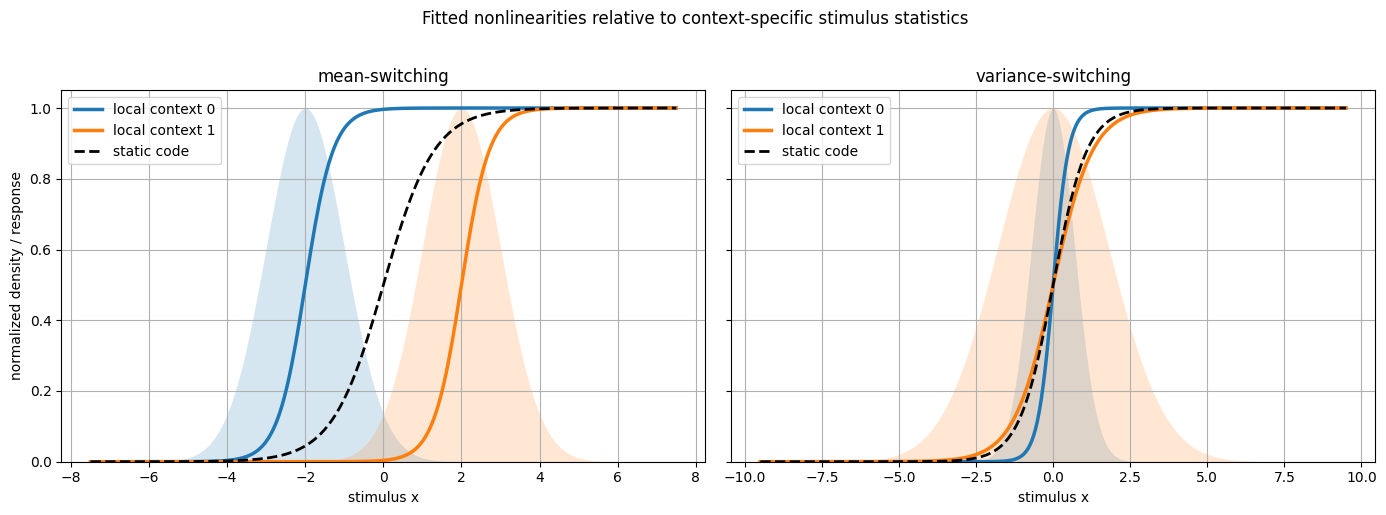

In [14]:
# ---------- fitted nonlinearities with context stimulus distributions ----------

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# ---------------- mean-switching ----------------
ax = axes[0]

for k, color in zip([0, 1], ["C0", "C1"]):
    mu = contexts_mean_default[k]["mu"]
    sigma = contexts_mean_default[k]["sigma"]

    pdf = scipy.stats.norm.pdf(x_grid_mean, loc=mu, scale=sigma)
    pdf = pdf / pdf.max()  # visual scaling only

    ax.fill_between(
        x_grid_mean,
        0,
        pdf,
        color=color,
        alpha=0.18,
        linewidth=0,
    )

    ax.plot(
        x_grid_mean,
        logistic(x_grid_mean, local_params_mean[k][0], local_params_mean[k][1]),
        color=color,
        lw=2.5,
        label=f"local context {k}",
    )

# static code
ax.plot(
    x_grid_mean,
    logistic(x_grid_mean, static_params_mean[0], static_params_mean[1]),
    color="black",
    lw=2,
    ls="--",
    label="static code",
)

ax.set_title("mean-switching")
ax.set_xlabel("stimulus x")
ax.set_ylabel("normalized density / response")
ax.set_ylim(0, 1.05)
ax.legend(frameon=True)

# ---------------- variance-switching ----------------
ax = axes[1]

for k, color in zip([0, 1], ["C0", "C1"]):
    mu = contexts_var_default[k]["mu"]
    sigma = contexts_var_default[k]["sigma"]

    pdf = scipy.stats.norm.pdf(x_grid_var, loc=mu, scale=sigma)
    pdf = pdf / pdf.max()

    ax.fill_between(
        x_grid_var,
        0,
        pdf,
        color=color,
        alpha=0.18,
        linewidth=0,
    )

    ax.plot(
        x_grid_var,
        logistic(x_grid_var, local_params_var[k][0], local_params_var[k][1]),
        color=color,
        lw=2.5,
        label=f"local context {k}",
    )

# static code
ax.plot(
    x_grid_var,
    logistic(x_grid_var, static_params_var[0], static_params_var[1]),
    color="black",
    lw=2,
    ls="--",
    label="static code",
)

ax.set_title("variance-switching")
ax.set_xlabel("stimulus x")
ax.set_ylim(0, 1.05)
ax.legend(frameon=True)

plt.suptitle("Fitted nonlinearities relative to context-specific stimulus statistics", y=1.02)
plt.tight_layout()
plt.show()

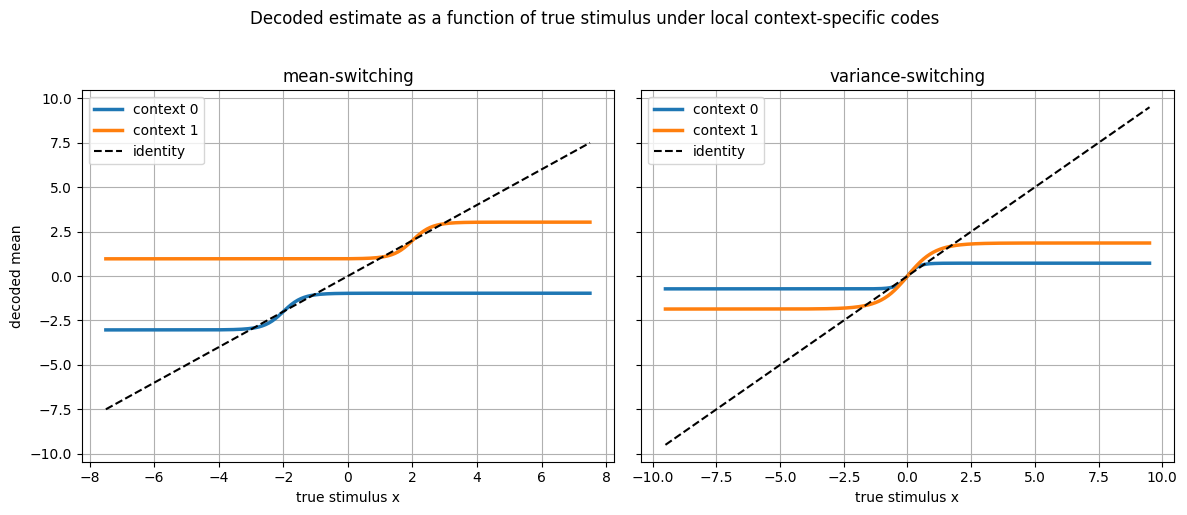

In [15]:
# ---------- decoded estimate vs stimulus ----------

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# mean-switching
ax = axes[0]
for k, color in zip([0, 1], ["C0", "C1"]):
    stats = posterior_stats_one_neuron(
        contexts_mean_default[k],
        local_params_mean[k][0],
        local_params_mean[k][1],
        x_grid_mean,
        response_sd=response_sd_default,
    )
    dec = decoded_mean_given_x_from_stats(stats)

    ax.plot(
        dec["x_grid"],
        dec["decoded_mean_given_x"],
        color=color,
        lw=2.5,
        label=f"context {k}",
    )

ax.plot(x_grid_mean, x_grid_mean, color="black", ls="--", lw=1.5, label="identity")
ax.set_title("mean-switching")
ax.set_xlabel("true stimulus x")
ax.set_ylabel("decoded mean")
ax.legend()

# variance-switching
ax = axes[1]
for k, color in zip([0, 1], ["C0", "C1"]):
    stats = posterior_stats_one_neuron(
        contexts_var_default[k],
        local_params_var[k][0],
        local_params_var[k][1],
        x_grid_var,
        response_sd=response_sd_default,
    )
    dec = decoded_mean_given_x_from_stats(stats)

    ax.plot(
        dec["x_grid"],
        dec["decoded_mean_given_x"],
        color=color,
        lw=2.5,
        label=f"context {k}",
    )

ax.plot(x_grid_var, x_grid_var, color="black", ls="--", lw=1.5, label="identity")
ax.set_title("variance-switching")
ax.set_xlabel("true stimulus x")
ax.legend()

plt.suptitle("Decoded estimate as a function of true stimulus under local context-specific codes", y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# ---------- hysteresis + refractory settings ----------

# refractory:
# number of time steps after a switch during which another switch is forbidden
refractory_default = 5
refractory_grid = [0, 2, 5, 10, 20]

# hysteresis:
# switch to context 1 only if P(1) > tau_high
# switch to context 0 only if P(1) < tau_low
tau_low_default = 0.35
tau_high_default = 0.65

hysteresis_grid = [
    (0.50, 0.50),   # effectively no hysteresis / plain threshold at 0.5
    (0.40, 0.60),
    (0.35, 0.65),
    (0.30, 0.70),
]


In [17]:
# ---------- baseline strategy comparison in default environments ----------

_, baseline_summary_mean = evaluate_baseline_strategies(
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
)

_, baseline_summary_var = evaluate_baseline_strategies(
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
)

display(baseline_summary_mean)
display(baseline_summary_var)

,strategy,n,global_mse_mean,global_mse_std,global_mse_sem,mismatch_rate_mean,mismatch_rate_std,mismatch_rate_sem,mean_mismatch_duration_mean,mean_mismatch_duration_std,mean_mismatch_duration_sem,mismatched_mse_mean,mismatched_mse_std,mismatched_mse_sem
0,oracle,20,0.281550,0.006334,0.001416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,adaptive_local,20,0.783451,0.055122,0.012326,0.052111,0.004964,0.00111,2.6386,0.15806,0.035343,9.905071,0.494294,0.110528
2,static,20,0.834066,0.016416,0.003671,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,strategy,n,global_mse_mean,global_mse_std,global_mse_sem,mismatch_rate_mean,mismatch_rate_std,mismatch_rate_sem,mean_mismatch_duration_mean,mean_mismatch_duration_std,mean_mismatch_duration_sem,mismatched_mse_mean,mismatched_mse_std,mismatched_mse_sem
0,oracle,20,0.537735,0.067306,0.015050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,adaptive_local,20,0.658116,0.074458,0.016649,0.180544,0.02445,0.005467,5.878493,0.744417,0.166457,1.282211,0.125588,0.028082
2,static,20,0.678417,0.060592,0.013549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


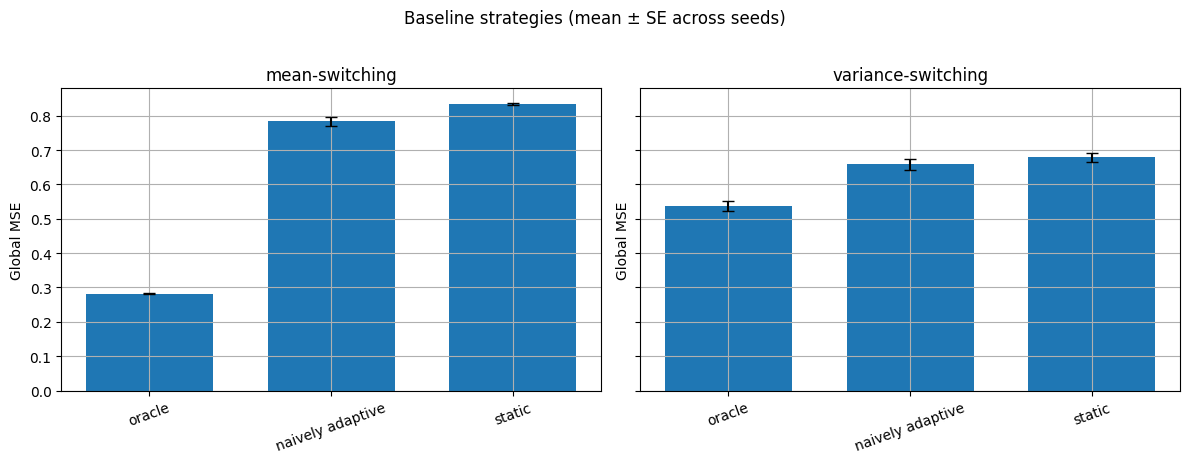

In [18]:
# ---------- baseline comparison plots ----------

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

strategy_order = ["oracle", "adaptive_local", "static"]
strategy_label_map = {
    "oracle": "oracle",
    "adaptive_local": "naively adaptive",
    "static": "static",
}

for ax, summary_df, env_name in [
    (axes[0], baseline_summary_mean, "mean-switching"),
    (axes[1], baseline_summary_var, "variance-switching"),
]:
    df_plot = summary_df.set_index("strategy").loc[strategy_order].reset_index()
    labels = [strategy_label_map[s] for s in df_plot["strategy"]]

    ax.bar(
        labels,
        df_plot["global_mse_mean"],
        yerr=df_plot["global_mse_sem"],
        capsize=4,
        width=0.7,
    )
    ax.set_title(env_name)
    ax.set_ylabel("Global MSE")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Baseline strategies (mean ± SE across seeds)", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# ---------- switching-mode comparisons in default environments ----------

_, switching_summary_mean = evaluate_switching_modes(
    contexts=contexts_mean_default,
    x_grid=x_grid_mean,
    local_params=local_params_mean,
    static_params=static_params_mean,
)

_, switching_summary_var = evaluate_switching_modes(
    contexts=contexts_var_default,
    x_grid=x_grid_var,
    local_params=local_params_var,
    static_params=static_params_var,
)

display(switching_summary_mean)
display(switching_summary_var)

,mode,n,global_mse_mean,global_mse_std,global_mse_sem,mismatch_rate_mean,mismatch_rate_std,mismatch_rate_sem,mean_mismatch_duration_mean,mean_mismatch_duration_std,mean_mismatch_duration_sem,mismatched_mse_mean,mismatched_mse_std,mismatched_mse_sem
0,hysteresis,20,0.794945,0.058106,0.012993,0.053500,0.005383,0.001204,4.025305,0.227079,0.050776,9.872885,0.476062,0.106451
1,instant,20,0.783451,0.055122,0.012326,0.052111,0.004964,0.001110,2.638600,0.158060,0.035343,9.905071,0.494294,0.110528
2,refractory,20,0.915361,0.067437,0.015079,0.066167,0.006571,0.001469,4.689420,0.220976,0.049412,9.858148,0.396098,0.088570


,mode,n,global_mse_mean,global_mse_std,global_mse_sem,mismatch_rate_mean,mismatch_rate_std,mismatch_rate_sem,mean_mismatch_duration_mean,mean_mismatch_duration_std,mean_mismatch_duration_sem,mismatched_mse_mean,mismatched_mse_std,mismatched_mse_sem
0,hysteresis,20,0.661277,0.071961,0.016091,0.185344,0.023990,0.005364,14.112994,1.803775,0.403336,1.285958,0.106215,0.023750
1,instant,20,0.658116,0.074458,0.016649,0.180544,0.024450,0.005467,5.878493,0.744417,0.166457,1.282211,0.125588,0.028082
2,refractory,20,0.660234,0.070941,0.015863,0.189022,0.021645,0.004840,9.810600,1.040365,0.232633,1.222955,0.116732,0.026102


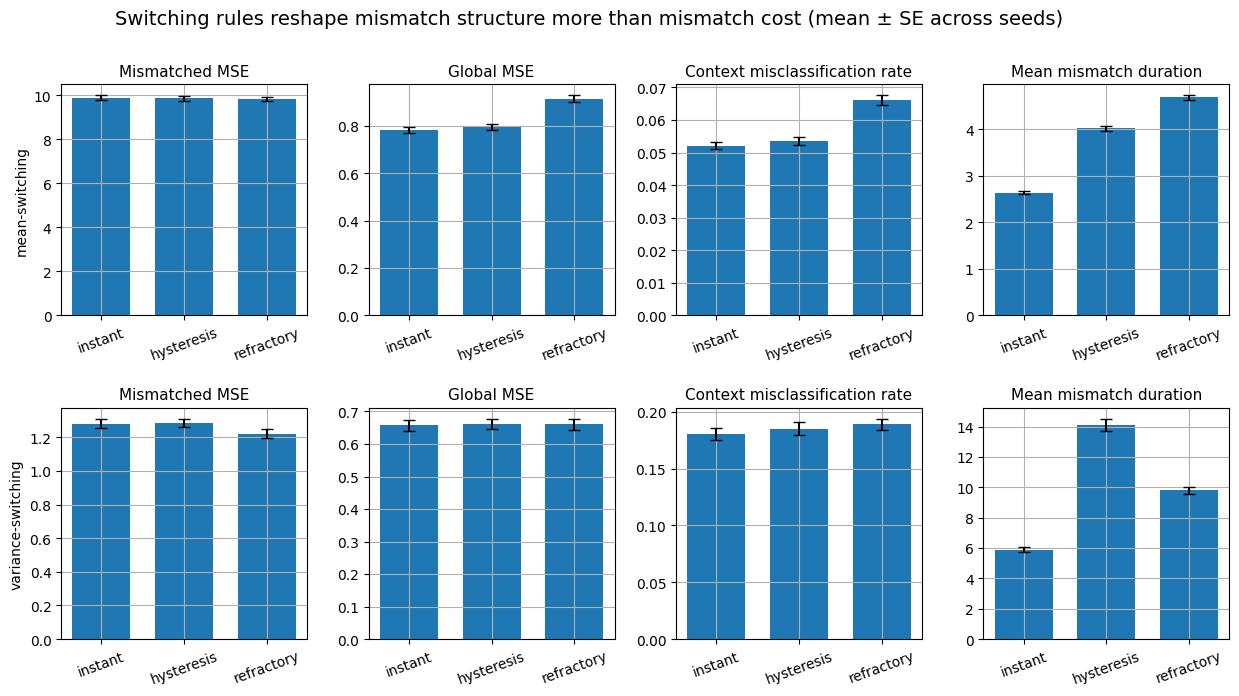

In [20]:
# ---------- merged Figure 3: switching-rule effects on mismatch cost and mismatch structure ----------

fig, axes = plt.subplots(2, 4, figsize=(16, 7.5), sharex=False)

mode_order = ["instant", "hysteresis", "refractory"]
mode_label_map = {
    "instant": "instant",
    "hysteresis": "hysteresis",
    "refractory": "refractory",
}

metric_specs = [
    ("mismatched_mse_mean", "mismatched_mse_sem", "Mismatched MSE"),
    ("global_mse_mean", "global_mse_sem", "Global MSE"),
    ("mismatch_rate_mean", "mismatch_rate_sem", "Context misclassification rate"),
    ("mean_mismatch_duration_mean", "mean_mismatch_duration_sem", "Mean mismatch duration"),
]

for row_idx, (summary_df, env_name) in enumerate([
    (switching_summary_mean, "mean-switching"),
    (switching_summary_var, "variance-switching"),
]):
    df_plot = summary_df.set_index("mode").loc[mode_order].reset_index()
    mode_labels = [mode_label_map[m] for m in df_plot["mode"]]

    for col_idx, (mean_col, err_col, metric_label) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        ax.bar(
            mode_labels,
            df_plot[mean_col],
            yerr=df_plot[err_col],
            capsize=4,
            width=0.7,
        )
        ax.set_title(metric_label, fontsize=11)
        ax.tick_params(axis="x", rotation=20)

        if col_idx == 0:
            ax.set_ylabel(env_name)

# cleaner spacing than tight_layout() for this figure shape
fig.suptitle(
    "Switching rules reshape mismatch structure more than mismatch cost (mean ± SE across seeds)",
    y=0.98,
    fontsize=14,
)

fig.subplots_adjust(
    left=0.17,
    right=0.90,
    bottom=0.14,
    top=0.88,
    wspace=0.25,
    hspace=0.40,
)

plt.show()

In [21]:
# ---------- hysteresis sweep in local adaptive model ----------

rows = []

for tau_low_now, tau_high_now in hysteresis_grid:
    for seed_now in seed_list:
        out_mean = run_strategy_one_neuron(
            strategy_name="adaptive",
            contexts=contexts_mean_default,
            x_grid=x_grid_mean,
            local_params=local_params_mean,
            static_params=static_params_mean,
            p_switch=p_switch_main,
            n_steps=n_steps_main,
            burn_in=burn_in_main,
            response_sd=response_sd_default,
            seed=seed_now,
            adaptation_mode="hysteresis",
            tau_low=tau_low_now,
            tau_high=tau_high_now,
        )

        out_var = run_strategy_one_neuron(
            strategy_name="adaptive",
            contexts=contexts_var_default,
            x_grid=x_grid_var,
            local_params=local_params_var,
            static_params=static_params_var,
            p_switch=p_switch_main,
            n_steps=n_steps_main,
            burn_in=burn_in_main,
            response_sd=response_sd_default,
            seed=seed_now,
            adaptation_mode="hysteresis",
            tau_low=tau_low_now,
            tau_high=tau_high_now,
        )

        rows.append({
            "env": "mean-switching",
            "seed": seed_now,
            "threshold_pair": f"({tau_low_now:.2f},{tau_high_now:.2f})",
            "tau_low": tau_low_now,
            "tau_high": tau_high_now,
            "global_mse": out_mean["global_mse"],
            "mismatch_rate": out_mean["mismatch_rate"],
            "mean_mismatch_duration": out_mean["mean_mismatch_duration"],
            "mismatched_mse": out_mean["mismatched_mse"],
        })

        rows.append({
            "env": "variance-switching",
            "seed": seed_now,
            "threshold_pair": f"({tau_low_now:.2f},{tau_high_now:.2f})",
            "tau_low": tau_low_now,
            "tau_high": tau_high_now,
            "global_mse": out_var["global_mse"],
            "mismatch_rate": out_var["mismatch_rate"],
            "mean_mismatch_duration": out_var["mean_mismatch_duration"],
            "mismatched_mse": out_var["mismatched_mse"],
        })

hysteresis_sweep_df = pd.DataFrame(rows)

hysteresis_sweep_summary = (
    hysteresis_sweep_df
    .groupby(["env", "threshold_pair", "tau_low", "tau_high"], as_index=False)
    .agg(
        global_mse_mean=("global_mse", "mean"),
        global_mse_sem=("global_mse", sem),
        mismatch_rate_mean=("mismatch_rate", "mean"),
        mismatch_rate_sem=("mismatch_rate", sem),
        mean_mismatch_duration_mean=("mean_mismatch_duration", "mean"),
        mean_mismatch_duration_sem=("mean_mismatch_duration", sem),
        mismatched_mse_mean=("mismatched_mse", "mean"),
        mismatched_mse_sem=("mismatched_mse", sem),
    )
)

display(hysteresis_sweep_summary)

,env,threshold_pair,tau_low,tau_high,global_mse_mean,global_mse_sem,mismatch_rate_mean,mismatch_rate_sem,mean_mismatch_duration_mean,mean_mismatch_duration_sem,mismatched_mse_mean,mismatched_mse_sem
0,mean-switching,"(0.30,0.70)",0.30,0.70,0.798975,0.012544,0.054011,0.001151,4.425413,0.047204,9.857079,0.099418
1,mean-switching,"(0.35,0.65)",0.35,0.65,0.794945,0.012993,0.053500,0.001204,4.025305,0.050776,9.872885,0.106451
2,mean-switching,"(0.40,0.60)",0.40,0.60,0.791528,0.012793,0.052878,0.001138,3.547353,0.050925,9.918847,0.112855
3,mean-switching,"(0.50,0.50)",0.50,0.50,0.783451,0.012326,0.052111,0.001110,2.638600,0.035343,9.905071,0.110528
4,variance-switching,"(0.30,0.70)",0.30,0.70,0.664712,0.016626,0.190722,0.005447,16.540703,0.514793,1.278371,0.021499
5,variance-switching,"(0.35,0.65)",0.35,0.65,0.661277,0.016091,0.185344,0.005364,14.112994,0.403336,1.285958,0.023750
6,variance-switching,"(0.40,0.60)",0.40,0.60,0.660412,0.016546,0.183822,0.005462,11.655811,0.341519,1.282954,0.025779
7,variance-switching,"(0.50,0.50)",0.50,0.50,0.658116,0.016649,0.180544,0.005467,5.878493,0.166457,1.282211,0.028082


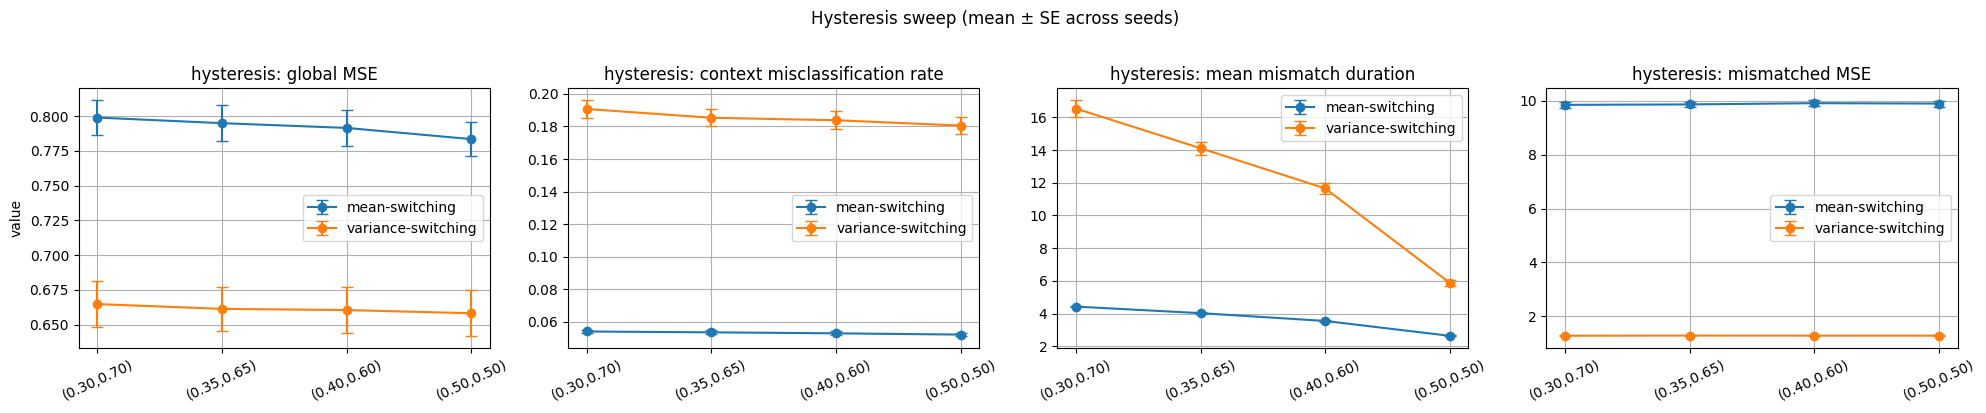

In [22]:
# ---------- hysteresis sweep plots ----------

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=False)

metric_specs = [
    ("global_mse_mean", "global_mse_sem", "global MSE"),
    ("mismatch_rate_mean", "mismatch_rate_sem", "context misclassification rate"),
    ("mean_mismatch_duration_mean", "mean_mismatch_duration_sem", "mean mismatch duration"),
    ("mismatched_mse_mean", "mismatched_mse_sem", "mismatched MSE"),
]

for env_name in ["mean-switching", "variance-switching"]:
    df_now = (
        hysteresis_sweep_summary[hysteresis_sweep_summary["env"] == env_name]
        .sort_values(["tau_low", "tau_high"])
        .reset_index(drop=True)
    )
    x = np.arange(len(df_now))
    labels = df_now["threshold_pair"].tolist()

    for ax, (mean_col, err_col, title) in zip(axes, metric_specs):
        ax.errorbar(
            x,
            df_now[mean_col],
            yerr=df_now[err_col],
            marker="o",
            capsize=4,
            label=env_name,
        )
        ax.set_title(f"hysteresis: {title}")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=25)
        ax.legend()

axes[0].set_ylabel("value")
plt.suptitle("Hysteresis sweep (mean ± SE across seeds)", y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# ---------- refractory sweep in local adaptive model ----------

rows = []

for refractory_now in refractory_grid:
    for seed_now in seed_list:
        out_mean = run_strategy_one_neuron(
            strategy_name="adaptive",
            contexts=contexts_mean_default,
            x_grid=x_grid_mean,
            local_params=local_params_mean,
            static_params=static_params_mean,
            p_switch=p_switch_main,
            n_steps=n_steps_main,
            burn_in=burn_in_main,
            response_sd=response_sd_default,
            seed=seed_now,
            adaptation_mode="refractory",
            refractory_length=refractory_now,
        )

        out_var = run_strategy_one_neuron(
            strategy_name="adaptive",
            contexts=contexts_var_default,
            x_grid=x_grid_var,
            local_params=local_params_var,
            static_params=static_params_var,
            p_switch=p_switch_main,
            n_steps=n_steps_main,
            burn_in=burn_in_main,
            response_sd=response_sd_default,
            seed=seed_now,
            adaptation_mode="refractory",
            refractory_length=refractory_now,
        )

        rows.append({
            "env": "mean-switching",
            "seed": seed_now,
            "refractory_length": refractory_now,
            "global_mse": out_mean["global_mse"],
            "mismatch_rate": out_mean["mismatch_rate"],
            "mean_mismatch_duration": out_mean["mean_mismatch_duration"],
            "mismatched_mse": out_mean["mismatched_mse"],
        })

        rows.append({
            "env": "variance-switching",
            "seed": seed_now,
            "refractory_length": refractory_now,
            "global_mse": out_var["global_mse"],
            "mismatch_rate": out_var["mismatch_rate"],
            "mean_mismatch_duration": out_var["mean_mismatch_duration"],
            "mismatched_mse": out_var["mismatched_mse"],
        })

refractory_sweep_df = pd.DataFrame(rows)

refractory_sweep_summary = (
    refractory_sweep_df
    .groupby(["env", "refractory_length"], as_index=False)
    .agg(
        global_mse_mean=("global_mse", "mean"),
        global_mse_sem=("global_mse", sem),
        mismatch_rate_mean=("mismatch_rate", "mean"),
        mismatch_rate_sem=("mismatch_rate", sem),
        mean_mismatch_duration_mean=("mean_mismatch_duration", "mean"),
        mean_mismatch_duration_sem=("mean_mismatch_duration", sem),
        mismatched_mse_mean=("mismatched_mse", "mean"),
        mismatched_mse_sem=("mismatched_mse", sem),
    )
)

display(refractory_sweep_summary)


,env,refractory_length,global_mse_mean,global_mse_sem,mismatch_rate_mean,mismatch_rate_sem,mean_mismatch_duration_mean,mean_mismatch_duration_sem,mismatched_mse_mean,mismatched_mse_sem
0,mean-switching,0,0.783451,0.012326,0.052111,0.001110,2.638600,0.035343,9.905071,0.110528
1,mean-switching,2,0.823356,0.010680,0.056244,0.001028,3.684944,0.042184,9.912401,0.098034
2,mean-switching,5,0.915361,0.015079,0.066167,0.001469,4.689420,0.049412,9.858148,0.088570
3,mean-switching,10,1.089379,0.022762,0.084411,0.002193,6.327049,0.107774,9.851054,0.087488
4,mean-switching,20,1.435563,0.035281,0.119989,0.003556,9.554339,0.218627,9.900331,0.044729
5,variance-switching,0,0.658116,0.016649,0.180544,0.005467,5.878493,0.166457,1.282211,0.028082
6,variance-switching,2,0.659362,0.016221,0.184056,0.005131,7.898535,0.216707,1.251741,0.025890
7,variance-switching,5,0.660234,0.015863,0.189022,0.004840,9.810600,0.232633,1.222955,0.026102
8,variance-switching,10,0.664787,0.016430,0.202100,0.004185,12.268865,0.242638,1.180387,0.024865
9,variance-switching,20,0.683228,0.015986,0.233778,0.004701,16.368767,0.295486,1.166275,0.020981


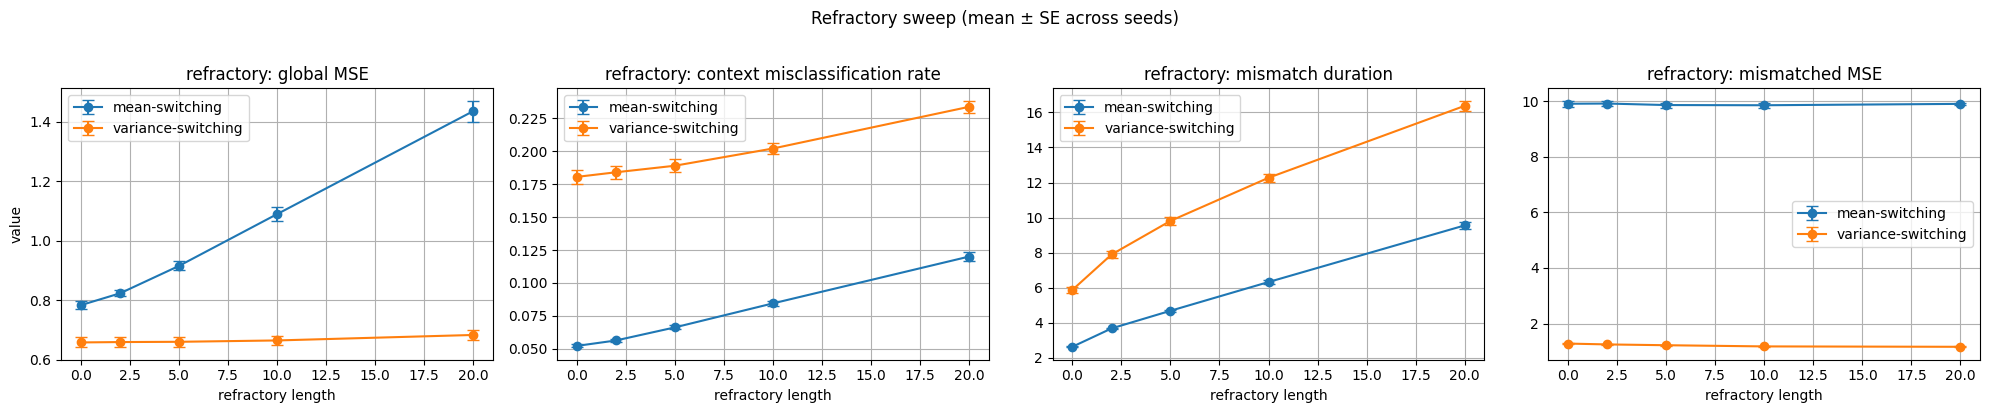

In [24]:
# ---------- refractory sweep plots ----------

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

metric_specs = [
    ("global_mse_mean", "global_mse_sem", "refractory: global MSE"),
    ("mismatch_rate_mean", "mismatch_rate_sem", "refractory: context misclassification rate"),
    ("mean_mismatch_duration_mean", "mean_mismatch_duration_sem", "refractory: mismatch duration"),
    ("mismatched_mse_mean", "mismatched_mse_sem", "refractory: mismatched MSE"),
]

for env_name in ["mean-switching", "variance-switching"]:
    df_now = refractory_sweep_summary[refractory_sweep_summary["env"] == env_name]

    for ax, (mean_col, err_col, title) in zip(axes, metric_specs):
        ax.errorbar(
            df_now["refractory_length"],
            df_now[mean_col],
            yerr=df_now[err_col],
            marker="o",
            capsize=4,
            label=env_name,
        )
        ax.set_title(title)
        ax.set_xlabel("refractory length")
        ax.legend()

axes[0].set_ylabel("value")
plt.suptitle("Refractory sweep (mean ± SE across seeds)", y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# ---------- mixed weak/strong separation sweep ----------

# choose one weak and one strong separation for each environment
# strong = your default environments
# weak = less separated versions

mean_context_sets = {
    "weak": make_mean_contexts(delta=2.0, sigma=1.0),
    "strong": contexts_mean_default,   # equivalent to delta = 4.0
}

var_context_sets = {
    "weak": make_variance_contexts(sigma_low=0.9, sigma_high=1.4, mu=0.0),
    "strong": contexts_var_default,    # sigma_low = 0.7, sigma_high = 1.8
}

fit_mixed = {
    ("mean", "weak"): fit_codebook_for_contexts(mean_context_sets["weak"], seed_offset=2000),
    ("mean", "strong"): fit_codebook_for_contexts(mean_context_sets["strong"], seed_offset=2500),
    ("variance", "weak"): fit_codebook_for_contexts(var_context_sets["weak"], seed_offset=3000),
    ("variance", "strong"): fit_codebook_for_contexts(var_context_sets["strong"], seed_offset=3500),
}

mode_specs = [
    ("instant", {
        "adaptation_mode": "instant",
        "tau_low": tau_low_default,
        "tau_high": tau_high_default,
        "refractory_length": 0,
    }),
    ("hysteresis", {
        "adaptation_mode": "hysteresis",
        "tau_low": tau_low_default,
        "tau_high": tau_high_default,
        "refractory_length": 0,
    }),
    ("refractory", {
        "adaptation_mode": "refractory",
        "tau_low": tau_low_default,
        "tau_high": tau_high_default,
        "refractory_length": refractory_default,
    }),
]

rows = []

for env_type, context_sets in [("mean", mean_context_sets), ("variance", var_context_sets)]:
    for separation, contexts_now in context_sets.items():
        fit_now = fit_mixed[(env_type, separation)]

        x_grid_now = fit_now["x_grid"]
        local_params_now = fit_now["local_params"]
        static_params_now = fit_now["static_params"]

        for mode_name, mode_kwargs in mode_specs:
            for seed_now in seed_list:
                out = run_strategy_one_neuron(
                    strategy_name="adaptive",
                    contexts=contexts_now,
                    x_grid=x_grid_now,
                    local_params=local_params_now,
                    static_params=static_params_now,
                    p_switch=p_switch_main,
                    n_steps=n_steps_main,
                    burn_in=burn_in_main,
                    response_sd=response_sd_default,
                    seed=seed_now,
                    adaptation_mode=mode_kwargs["adaptation_mode"],
                    tau_low=mode_kwargs["tau_low"],
                    tau_high=mode_kwargs["tau_high"],
                    refractory_length=mode_kwargs["refractory_length"],
                )

                rows.append({
                    "env_type": env_type,
                    "separation": separation,
                    "mode": mode_name,
                    "seed": seed_now,
                    "global_mse": out["global_mse"],
                    "mismatch_rate": out["mismatch_rate"],
                    "mean_mismatch_duration": out["mean_mismatch_duration"],
                    "mismatched_mse": out["mismatched_mse"],
                })

mixed_sweep_df = pd.DataFrame(rows)

mixed_sweep_summary = (
    mixed_sweep_df
    .groupby(["env_type", "separation", "mode"], as_index=False)
    .agg(
        global_mse=("global_mse", "mean"),
        mismatch_rate=("mismatch_rate", "mean"),
        mean_mismatch_duration=("mean_mismatch_duration", "mean"),
        mismatched_mse=("mismatched_mse", "mean"),
        global_mse_sem=("global_mse", sem),
        mismatch_rate_sem=("mismatch_rate", sem),
        mean_mismatch_duration_sem=("mean_mismatch_duration", sem),
        mismatched_mse_sem=("mismatched_mse", sem),
    )
)

display(mixed_sweep_summary)

,env_type,separation,mode,global_mse,mismatch_rate,mean_mismatch_duration,mismatched_mse,global_mse_sem,mismatch_rate_sem,mean_mismatch_duration_sem,mismatched_mse_sem
0,mean,strong,hysteresis,0.794948,0.053500,4.025305,9.872939,0.012993,0.001204,0.050776,0.106451
1,mean,strong,instant,0.783454,0.052111,2.638600,9.905126,0.012326,0.001110,0.035343,0.110528
2,mean,strong,refractory,0.915365,0.066167,4.689420,9.858203,0.015079,0.001469,0.049412,0.088571
3,mean,weak,hysteresis,0.385894,0.062656,4.626423,1.954476,0.002972,0.001516,0.066640,0.037782
4,mean,weak,instant,0.386045,0.061522,2.906487,1.980674,0.003430,0.001624,0.050975,0.038794
5,mean,weak,refractory,0.407302,0.075700,5.150500,1.943800,0.003786,0.001844,0.045111,0.036897
6,variance,strong,hysteresis,0.661277,0.185344,14.112994,1.285958,0.016091,0.005364,0.403336,0.023750
7,variance,strong,instant,0.658116,0.180544,5.878493,1.282211,0.016649,0.005467,0.166457,0.028082
8,variance,strong,refractory,0.660234,0.189022,9.810600,1.222955,0.015863,0.004840,0.232633,0.026102
9,variance,weak,hysteresis,0.437650,0.303511,28.743790,0.543251,0.007022,0.009476,0.806796,0.009584


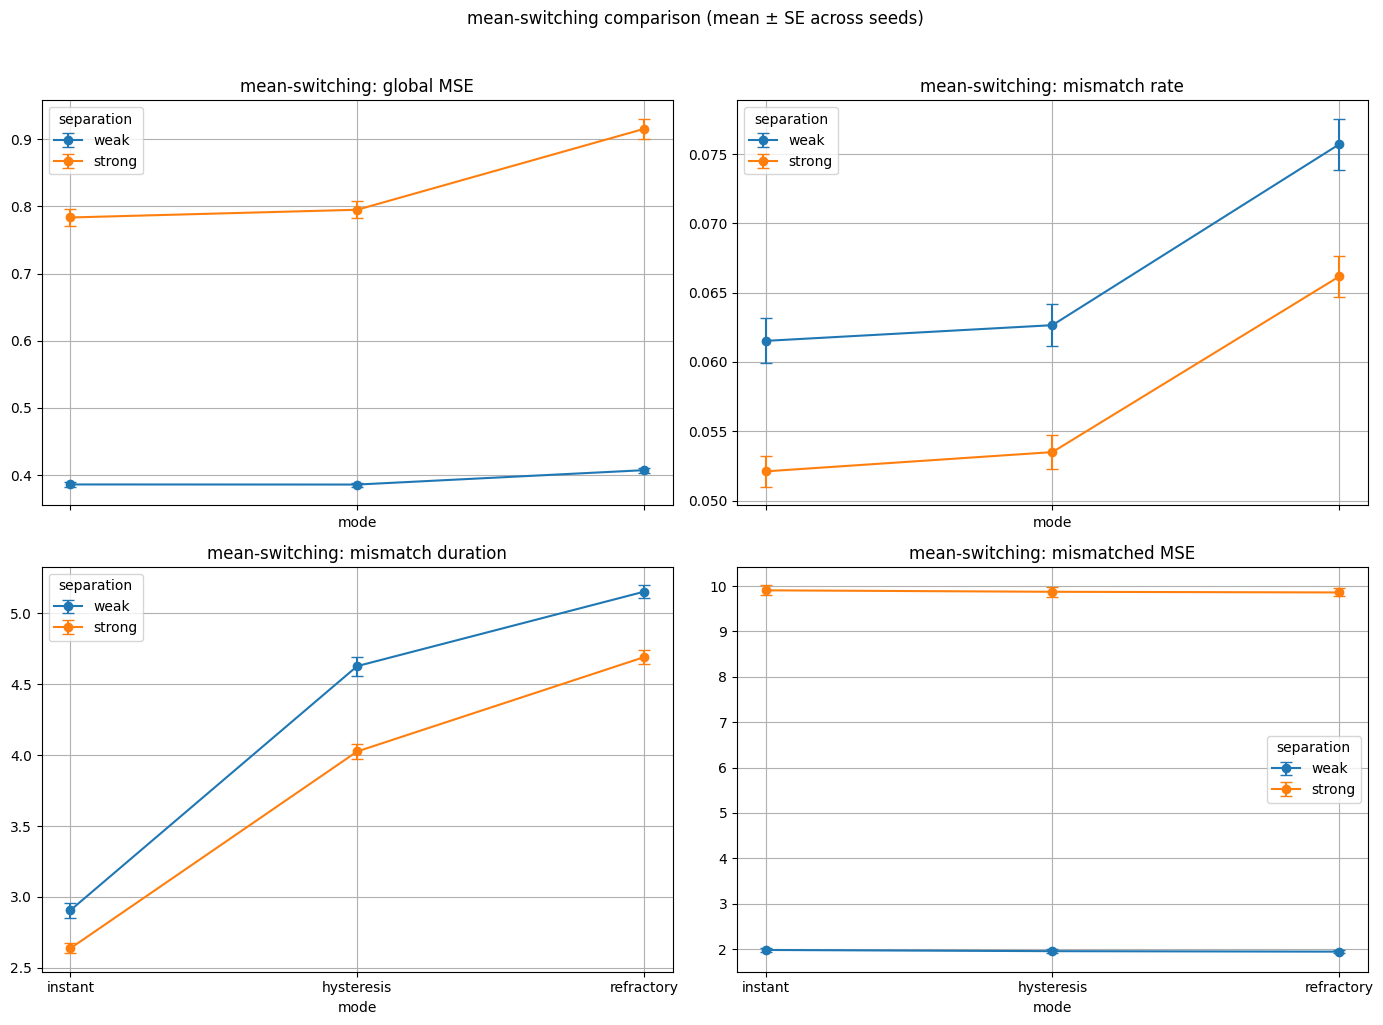

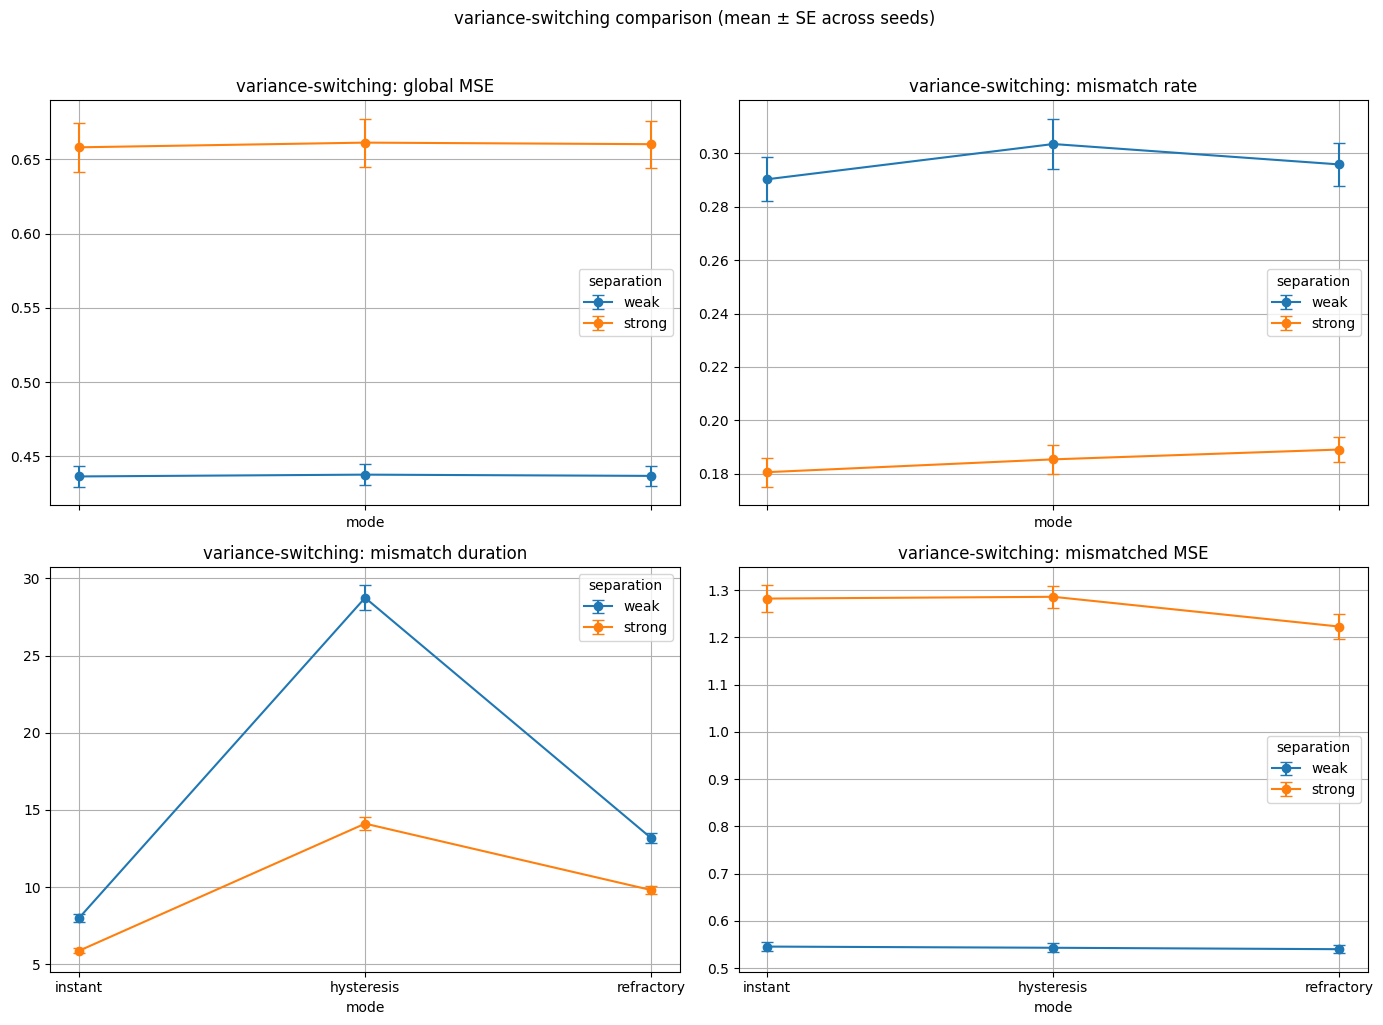

In [26]:
# ---------- plot mixed sweep results ----------

mode_order = ["instant", "hysteresis", "refractory"]

for env_type in ["mean", "variance"]:
    df_env = mixed_sweep_summary[mixed_sweep_summary["env_type"] == env_type].copy()
    df_env["mode"] = pd.Categorical(df_env["mode"], categories=mode_order, ordered=True)
    df_env = df_env.sort_values(["separation", "mode"])

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

    metric_info = [
        ("global_mse", "global_mse_sem", f"{env_type}-switching: global MSE"),
        ("mismatch_rate", "mismatch_rate_sem", f"{env_type}-switching: mismatch rate"),
        ("mean_mismatch_duration", "mean_mismatch_duration_sem", f"{env_type}-switching: mismatch duration"),
        ("mismatched_mse", "mismatched_mse_sem", f"{env_type}-switching: mismatched MSE"),
    ]

    for separation in ["weak", "strong"]:
        df_sep = df_env[df_env["separation"] == separation].copy()

        axes[0, 0].errorbar(
            df_sep["mode"], df_sep["global_mse"],
            yerr=df_sep["global_mse_sem"], marker="o", capsize=4, label=separation
        )
        axes[0, 1].errorbar(
            df_sep["mode"], df_sep["mismatch_rate"],
            yerr=df_sep["mismatch_rate_sem"], marker="o", capsize=4, label=separation
        )
        axes[1, 0].errorbar(
            df_sep["mode"], df_sep["mean_mismatch_duration"],
            yerr=df_sep["mean_mismatch_duration_sem"], marker="o", capsize=4, label=separation
        )
        axes[1, 1].errorbar(
            df_sep["mode"], df_sep["mismatched_mse"],
            yerr=df_sep["mismatched_mse_sem"], marker="o", capsize=4, label=separation
        )

    for ax, (_, _, title) in zip(axes.ravel(), metric_info):
        ax.set_title(title)
        ax.set_xlabel("mode")
        ax.legend(title="separation")

    plt.suptitle(f"{env_type}-switching comparison (mean ± SE across seeds)", y=1.02)
    plt.tight_layout()
    plt.show()

In [27]:
# ---------- small p_switch robustness check ----------

p_switch_grid_small = [0.005, 0.01, 0.02]

rows = []

for p_switch_now in p_switch_grid_small:
    _, mean_summary_now = evaluate_switching_modes(
        contexts=contexts_mean_default,
        x_grid=x_grid_mean,
        local_params=local_params_mean,
        static_params=static_params_mean,
        seeds=seed_list,
        p_switch=p_switch_now,
    )

    _, var_summary_now = evaluate_switching_modes(
        contexts=contexts_var_default,
        x_grid=x_grid_var,
        local_params=local_params_var,
        static_params=static_params_var,
        seeds=seed_list,
        p_switch=p_switch_now,
    )

    for env_name, summary_df in [
        ("mean-switching", mean_summary_now),
        ("variance-switching", var_summary_now),
    ]:
        for _, row in summary_df.iterrows():
            rows.append({
                "env": env_name,
                "p_switch": p_switch_now,
                "mode": row["mode"],
                "global_mse_mean": row["global_mse_mean"],
                "global_mse_sem": row["global_mse_sem"],
                "mismatch_rate_mean": row["mismatch_rate_mean"],
                "mismatch_rate_sem": row["mismatch_rate_sem"],
                "mean_mismatch_duration_mean": row["mean_mismatch_duration_mean"],
                "mean_mismatch_duration_sem": row["mean_mismatch_duration_sem"],
                "mismatched_mse_mean": row["mismatched_mse_mean"],
                "mismatched_mse_sem": row["mismatched_mse_sem"],
            })

p_switch_robust_df = pd.DataFrame(rows)
display(p_switch_robust_df)

,env,p_switch,mode,global_mse_mean,global_mse_sem,mismatch_rate_mean,mismatch_rate_sem,mean_mismatch_duration_mean,mean_mismatch_duration_sem,mismatched_mse_mean,mismatched_mse_sem
0,mean-switching,0.005,hysteresis,0.611201,0.014172,0.033489,0.001504,4.499069,0.100949,10.170319,0.133907
1,mean-switching,0.005,instant,0.595267,0.014686,0.032178,0.001448,3.038934,0.087677,10.055524,0.136099
2,mean-switching,0.005,refractory,0.683526,0.014949,0.041578,0.001566,5.229599,0.045500,9.970829,0.107521
3,variance-switching,0.005,hysteresis,0.606781,0.018895,0.137356,0.005383,18.122915,0.509939,1.278140,0.033373
4,variance-switching,0.005,instant,0.603470,0.019249,0.134933,0.005312,7.466399,0.201979,1.256783,0.030292
5,variance-switching,0.005,refractory,0.606343,0.019519,0.140100,0.004943,12.076244,0.223632,1.216178,0.031407
6,mean-switching,0.010,hysteresis,0.794945,0.012993,0.053500,0.001204,4.025305,0.050776,9.872885,0.106451
7,mean-switching,0.010,instant,0.783451,0.012326,0.052111,0.001110,2.638600,0.035343,9.905071,0.110528
8,mean-switching,0.010,refractory,0.915361,0.015079,0.066167,0.001469,4.689420,0.049412,9.858148,0.088570
9,variance-switching,0.010,hysteresis,0.661277,0.016091,0.185344,0.005364,14.112994,0.403336,1.285958,0.023750


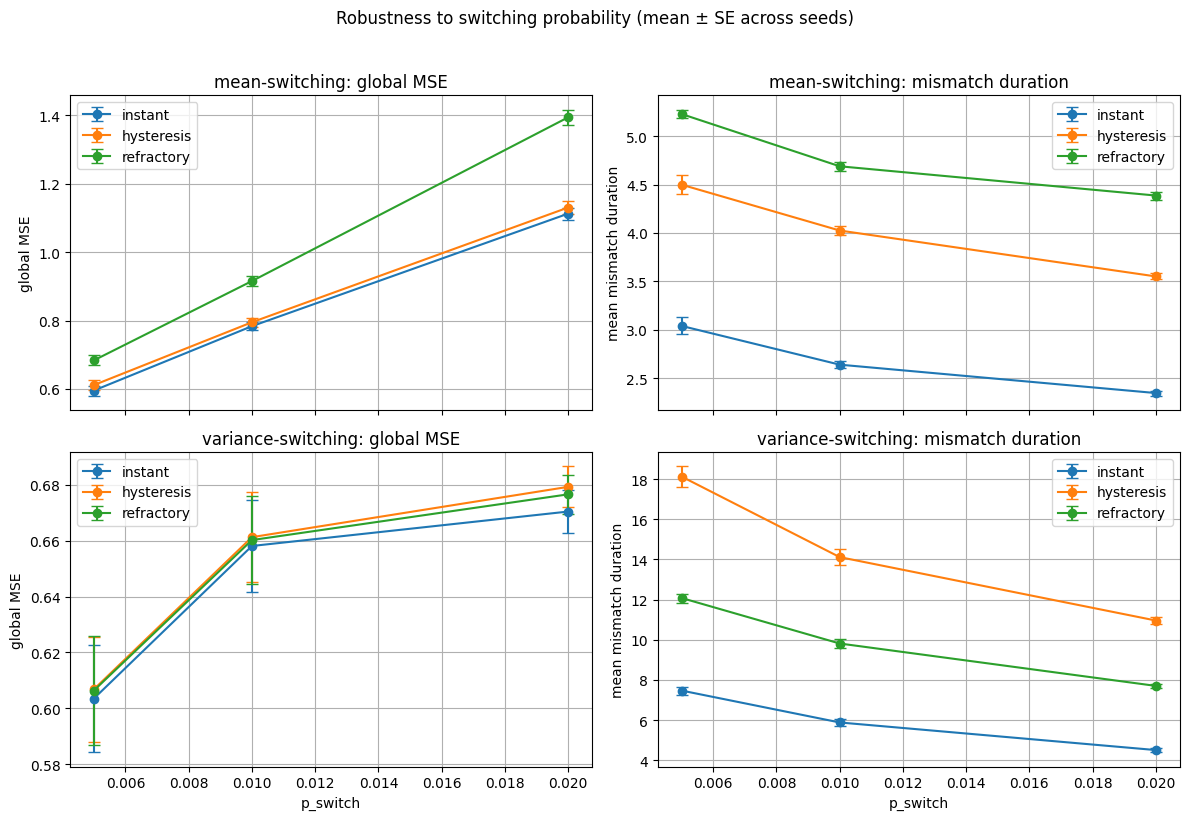

In [28]:
# ---------- small p_switch robustness plots ----------

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for row_idx, env_name in enumerate(["mean-switching", "variance-switching"]):
    df_env = p_switch_robust_df[p_switch_robust_df["env"] == env_name]

    for mode_name in ["instant", "hysteresis", "refractory"]:
        df_mode = df_env[df_env["mode"] == mode_name].sort_values("p_switch")

        axes[row_idx, 0].errorbar(
            df_mode["p_switch"],
            df_mode["global_mse_mean"],
            yerr=df_mode["global_mse_sem"],
            marker="o",
            capsize=4,
            label=mode_name,
        )
        axes[row_idx, 1].errorbar(
            df_mode["p_switch"],
            df_mode["mean_mismatch_duration_mean"],
            yerr=df_mode["mean_mismatch_duration_sem"],
            marker="o",
            capsize=4,
            label=mode_name,
        )

    axes[row_idx, 0].set_title(f"{env_name}: global MSE")
    axes[row_idx, 0].set_ylabel("global MSE")
    axes[row_idx, 0].legend()

    axes[row_idx, 1].set_title(f"{env_name}: mismatch duration")
    axes[row_idx, 1].set_ylabel("mean mismatch duration")
    axes[row_idx, 1].legend()

axes[1, 0].set_xlabel("p_switch")
axes[1, 1].set_xlabel("p_switch")
plt.suptitle("Robustness to switching probability (mean ± SE across seeds)", y=1.02)
plt.tight_layout()
plt.show()